In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

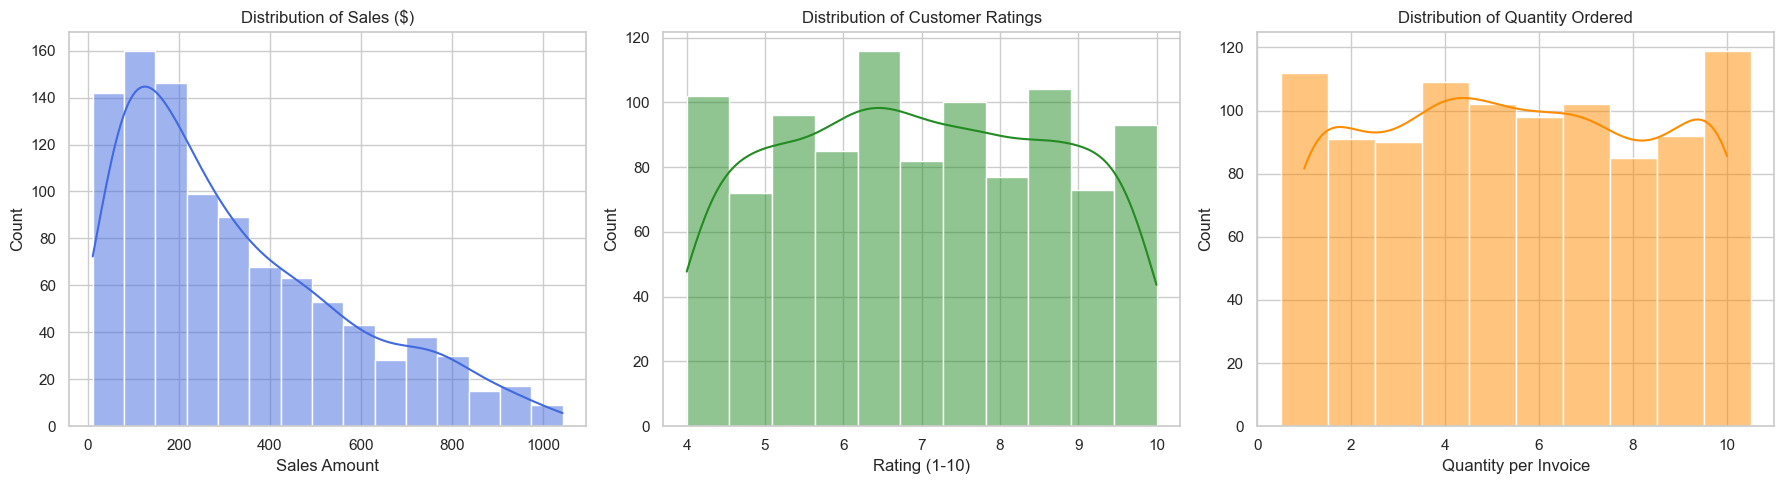

In [12]:
# Plot distributions for all 3 numerical columns: Sales, Rating, Quantity
# Use sns.histplot() with kde=True for each. kde=True adds a smooth curve showing the distribution shape.

df = pd.read_csv("SuperMarket Analysis.csv")

# Set up the matplotlib figure style and size
# .set_theme handles all the graph background , fonts ,and look and feel

sns.set_theme(style="whitegrid")

# 1,3 means 1 row and 3 columns    18 means width size and 5 means height wise
# fig will hold all the 3 plots   axes act as list will store address of axes[0], axes[1]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))



# 1. Distribution of Sales

# sns.histplot work is to make histogram graph
#Kernel Density Estimate. True karne se histogram ke bars  ek smooth, ghumavdar trend line (curve) ban jati hai hai
sns.histplot(data=df, x='Sales', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Sales ($)')
axes[0].set_xlabel('Sales Amount')
axes[0].set_ylabel('Count')

# 2. Distribution of Rating
sns.histplot(data=df, x='Rating', kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribution of Customer Ratings')
axes[1].set_xlabel('Rating (1-10)')
axes[1].set_ylabel('Count')

# 3. Distribution of Quantity
sns.histplot(data=df, x='Quantity', kde=True, ax=axes[2], color='darkorange', discrete=True)
axes[2].set_title('Distribution of Quantity Ordered')
axes[2].set_xlabel('Quantity per Invoice')
axes[2].set_ylabel('Count')

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()


In [14]:

#Q2
# Identify outliers in Sales using the IQR method
# Q1 = df['Sales'].quantile(0.25), Q3 = df['Sales'].quantile(0.75), IQR = Q3 - Q1. 
# Outliers: below Q1-1.5*IQR or above Q3+1.5*IQR


# IQR (Interquartile Range) Method ya Tukey's Boxplot Method kehte hain.

# Step 1: Calculate Q1, Q3, and IQR

# df['Sales'].quantile(0.25): quantile(0.25) ka matlab hai 25th Percentile. Agar aap dukan ke saare 1,000 bills 
# ko line se chote se bada karke khada kar dein, toh shuruat ke 25% jahan khatam hote hain, woh rate hai $124.42. 
# Isse chote bills saste bills hote hain.


# df['Sales'].quantile(0.75): quantile(0.75) ka matlab hai 75th Percentile. Line mein khade bills ka 75% hissa jahan
# khatam hota hai, woh rate hai $471.35. Isse bade bills bohot mehenge bills hote hain.


# IQR = Q3 - Q1: IQR ka full form hai Interquartile Range. Yeh hume batata hai ki dukan ke jo sabse aam (normal)
# 50% beech wale customers hain, unke bills ki range kitni chodi hai ($471.35 - $124.42 = $346.93).

Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define boundaries (fences)

# ek boundary (fences), jiske baahar jaate hi bill ko "Ajeeb" ya "Outlier" bol diya jayega. 
# Iske liye duniya ka standard rule hai ki IQR ko 1.5 se multiply karo.


# lower_bound = Q1 - 1.5 * IQR: Saste bills ki hadd. Yeh minus mein chali jaati hai (124.42 - 1.5 * 346.93), 
# isliye isko hum zero ($0) maan lete hain kyunki bill minus mein nahi ho sakta.


# upper_bound = Q3 + 1.5 * IQR: Mehenge bills ki extreme hadd (Laxman Rekha).


# ska matlab agar koi customer ek baar mein $991.74 se zyada ka samaan khareedta hai, 
# toh computer use ek normal transaction nahi, balki ek extreme outlier bolega.

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR




# df['Sales'] < lower_bound: Computer se kaha, "Woh bills lao jo $0 se bhi kam hon" (Aisa koi nahi milega).
# |: Iska matlab hota hai "YA FIR" (OR).
# df['Sales'] > upper_bound: "Ya fir woh bills lao jo $991.74 se bade hon."


# df['Sales'] < lower_bound: Computer se kaha, "Woh bills lao jo $0 se bhi kam hon" (Aisa koi nahi milega).
# |: Iska matlab hota hai "YA FIR" (OR).
# df['Sales'] > upper_bound: "Ya fir woh bills lao jo $991.74 se bade hon."



# Step 3: Filter the outliers
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

print(f"--- IQR Outlier Summary ---")
print(f"25th Percentile (Q1): ${Q1:.2f}")
print(f"75th Percentile (Q3): ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower Boundary (Min Safe): ${lower_bound:.2f}")
print(f"Upper Boundary (Max Safe): ${upper_bound:.2f}")
print(f"Total Outliers Detected: {len(outliers)} rows")

if len(outliers) > 0:
    print("\n--- Top 5 Outlier Transactions ---")

    # .head(): Yeh top 5 sabse bade vip bills aapki screen par show kar deta hai.
    display(outliers[['Invoice ID', 'Product line', 'Sales']].sort_values(by='Sales', ascending=False).head())


--- IQR Outlier Summary ---
25th Percentile (Q1): $124.42
75th Percentile (Q3): $471.35
IQR: $346.93
Lower Boundary (Min Safe): $-395.97
Upper Boundary (Max Safe): $991.74
Total Outliers Detected: 9 rows

--- Top 5 Outlier Transactions ---


,Invoice ID,Product line,Sales
350,860-79-0874,Fashion accessories,1042.65
167,687-47-8271,Fashion accessories,1039.29
557,283-26-5248,Food and beverages,1034.46
699,751-41-9720,Home and lifestyle,1023.75
996,303-96-2227,Home and lifestyle,1022.49


C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_8284\2227377021.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette="viridis")
C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_8284\2227377021.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette="viridis")
C:\Users\KAMRAN TECH\AppData\Local\Temp\ipykernel_8284\2227377021.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette="viridis")
C:\Users\K

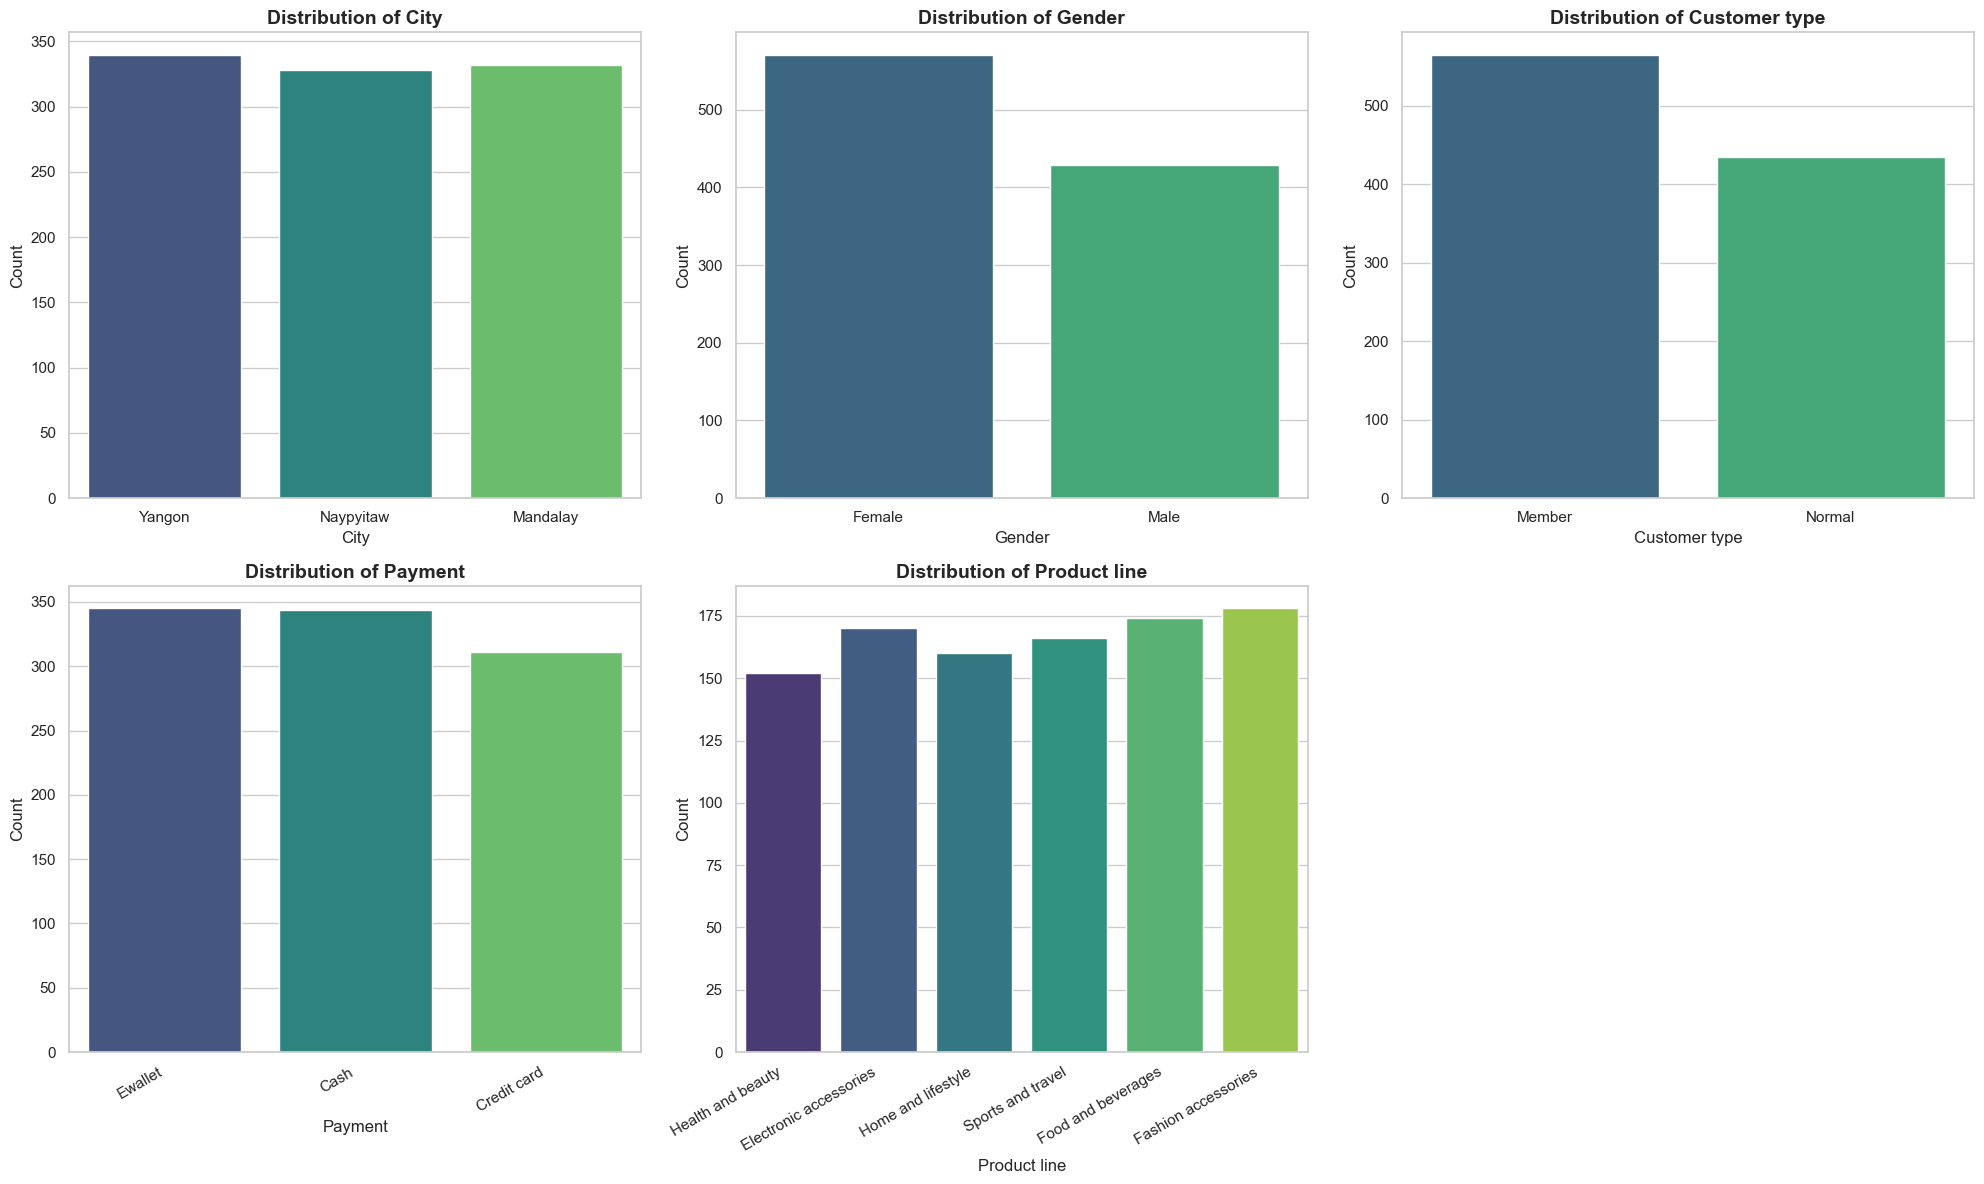

In [15]:
# Plot countplots for all categorical columns
# sns.countplot() shows how many rows belong to each category. Do it for City, Gender, Customer type, Payment, Product line.

# Step 1: Theme aur layout ka size set karein (2 Rows, 3 Columns)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(20, 12))


# Humare categorical columns ki list
cat_cols = ['City', 'Gender', 'Customer type', 'Payment', 'Product line']


# Step 2: Loop chala kar har ek dabbe mein graph fit karna


# Normal for col in cat_cols likhne se hume sirf column ka naam milta (jaise 'City', 'Gender'). 
# Lekin humne likha for i, col in enumerate(cat_cols).


# enumerate hume naam ke sath-sath uska index (position number) bhi deta hai.
# Jab loop chalega, toh computer ko do cheezein milengi:
# Round 1: i = 0, col = 'City'
# Round 2: i = 1, col = 'Gender'



for i, col in enumerate(cat_cols):
    # Yeh maths nikaalta hai ki graph kaunsi row aur kaunse column mein jayega


    # Humne pehle plt.subplots(2, 3) likh kar computer se 2 Rows aur 3 Columns ka ek grid (matrix) manga tha, 
    # jisme total 6 dabbe hain. Ab computer ko kaise pata chalega ki i = 3 (Payment) wale graph ko kaunse dabbe 
    # mein baithana hai? Uske liye yeh chota sa maths use hota hai:

# // (Floor Division): Yeh divide karne ke baad point (.) ke baad wali value ko hata deta hai
# (sirf poora number leta hai). Yeh hume batata hai Row Number.

# % (Modulus): Yeh divide karne ke baad jo remainder (bacha hua shesh) hota hai, woh batata hai. Isse hume pata chalta hai Column Number.
    
    row = i // 3
    col_idx = i % 3
    
    # Actual countplot banana

# ax=axes[row, col_idx]: Humne Seaborn ko bataya ki is round ka graph uthao aur jo upar humne 
# row aur col_idx ka address nikala hai, usi dabbe mein isko plot kar do.
    sns.countplot(data=df, x=col, ax=axes[row, col_idx], palette="viridis")

    
    # Styling aur labels
    axes[row, col_idx].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[row, col_idx].set_xlabel(col, fontsize=12)
    axes[row, col_idx].set_ylabel('Count', fontsize=12)
    
    # Agar column 'Product line' hai, toh uske bade naamon ko thoda tedha (rotate) kar do
    if col == 'Product line' or col == 'Payment':
        
#  axes[row, col_idx]: Yeh hamare us specific dabbe (subplot) ka address hai jo abhi loop mein chal raha hai.
# .set_xticklabels(...): Yeh matplotlib ka ek function hai. Iska kaam hota hai X-axis (niche waali horizontal line)
# par jo text labels likhe hain (jaise Cash, Ewallet, Fashion, etc.), unki settings ya design ko badalna

        
        
# .set_xticklabels ko chalne ke liye pehle yeh pata hona chahiye ki abhi wahan par kaunse text likhe hue hain.
# Yeh function un saare naamon ko "get" (utha kar) lekar aata hai taaki hum un par nayi settings apply kar sakein.
        
    
        axes[row, col_idx].set_xticklabels(axes[row, col_idx].get_xticklabels(), rotation=30, ha='right')

# Step 3: Jo aakhri 6th dabba khali bacha hai, use mita do (hide kar do)



# fig: Yeh hamare us bade canvas (board) ka naam hai jiske andar saare plots baithe hue hain.
# .delaxes(...): Iska full form hai "Delete Axis". Yeh matplotlib ka ek special command hai jiska kaam hota hai pure board (fig)
# mein se kisi ek specific khali dabbe (subplot) ko dhoond kar mita dena ya gayab kar dena.
# axes: Yeh hamare saare dabbo ki address list hai.
# [1, 2]: Yeh us khali dabbe ka exact address (index location) hai jise hum hatana chahte hain:
# 1 ka matlab hai Row number 1 (yaani dusri line, kyunki counting 0 se shuru hoti hai).
# 2 ka matlab hai Column number 2 (yaani tisra khada dabba).

fig.delaxes(axes[1, 2])

# Layout ko clean karke show karna
plt.tight_layout()
plt.show()





In [16]:
# Find the most and least balanced categories
# If one city has 340 transactions and another has 328, that is balanced. If one had 600 and another 100, that is imbalanced 
# — important for ML later.



# 1. City column ka exact count aur percentage nikalna

# .value_counts(): Yeh pandas ka ek bahut hi mahan function hai. Iska kaam hai column ke andar jana
# aur ginti karna ki har ek city ka naam pure table mein kitni baar
# aaya hai (jaise Yangon: 340, Mandalay: 332, etc.).

city_counts = df['City'].value_counts()

# normalize=True: value_counts ke andar jab hum yeh likhte hain, toh computer hume ginti (counts) 
# nahi deta, balki unka proportions (hissa ya ratio) nikaal kar deta hai decimals mein (jaise 0.34, 0.33).


# * 100: Decimals ko normal percentage mein badalne ke liye humne 
# use 100 se multiply kar diya (jaise 0.34 * 100 = 34.0%).

city_percentages = df['City'].value_counts(normalize=True) * 100



print("=== City Balance Check ===")

# city_counts.index ke paas teeno shahron ke naam hain (Yangon, Mandalay, Naypyitaw). 
# Yeh loop ek-ek karke har shahar ka naam uthayega aur use city variable mein daalega.

for city in city_counts.index:
    
    # {city:<12}: Yeh ek professional formatting trick hai. Iska matlab hai city ka naam print karo
    # aur uske aage 12 characters ki khali jagah chhor do (left-align). Isse saare shahron ke naam ek 
    # hi line mein barabar dikhte hain, aage-piche nahi hote.
    
    print(f"City: {city:<12} | Transactions: {city_counts[city]:<4} | Share: {city_percentages[city]:.2f}%")


# 2. ML ke liye automatic alert system (Imbalance Detector)
# Rule: Agar koi bhi category total data ka 50% se zyada akeli le jaye, toh alert do.

# .max(): Yeh city_percentages mein se sabse badi percentage (sabse bade shahar ka share, jaise 34.0%)
# dhoondh nikaalta hai.

max_share = city_percentages.max()
min_share = city_percentages.min()


print("\n=== ML Readiness Verdict ===")
# max_share / min_share: Yeh ek professional trick hai. Agar sabse badi city aur sabse
# choti city ka ratio 2 se bada ho jaye (matlab ek dukan dusri se dugni badi hai),
# toh computer samajh jata hai ki data imbalanced hai.

if max_share / min_share > 2.0:  # Agar sabse badi category sabse choti se dugni badi ho
    print(f"⚠️ ALERT: Data is Imbalanced! Max/Min ratio is {max_share/min_share:.2f}. ML models might get biased.")
else:
    print(f"✅ SUCCESS: Data is perfectly Balanced! Max/Min ratio is {max_share/min_share:.2f}. Safe for Machine Learning.")
    

=== City Balance Check ===
City: Yangon       | Transactions: 340  | Share: 34.00%
City: Mandalay     | Transactions: 332  | Share: 33.20%
City: Naypyitaw    | Transactions: 328  | Share: 32.80%

=== ML Readiness Verdict ===
✅ SUCCESS: Data is perfectly Balanced! Max/Min ratio is 1.04. Safe for Machine Learning.


In [17]:
# Second method for balance / imbalancing

import numpy as np

# Step 1: Har city ka proportion (p) nikalna
proportions = df['City'].value_counts(normalize=True)


# np.sum(proportions  2)np: NumPy library ka alias hai jo tezi se maths karne ke kaam aati hai. 2: Python mein 

# double asterisks () ka matlab hota hai Power (Square). Yeh har city ke ratio ka square kar raha hai 

# (jaise $0.333^2 = 0.1108$).np.sum(...): Yeh un teeno shahron ke squares ko aapas mein add (jod) kar deta hai 

# ($0.1108 + 0.1108 + 0.1108 = 0.3324$).gini_impurity = 1 - ...Yeh asal mein Machine Learning ka standard formula hai.

# Rule: Agar saare 1000 transactions sirf ek hi city mein hote (Extreme Imbalance), toh Gini Impurity ka answer aata 0.0

# (No impurity/Bilkul Shudh).Agar data 3 cities mein perfectly barabar baanta ho (Perfect Balance), toh iska maximum answer 
# aata hai 0.666

# Step 2: Gini Impurity ka formula lagana (1 - sum(p^2))
gini_impurity = 1 - np.sum(proportions ** 2)

print("=== Gini Impurity Balance Check ===")
print(f"Calculated Gini Score: {gini_impurity:.4f}")

# Step 3: Automatically check default thresholds
if gini_impurity < 0.20:
    print("⚠️ ALERT: High Imbalance! Data is heavily leaning towards one city.")
elif gini_impurity > 0.60:
    print("✅ SUCCESS: High Diversity! Transactions are perfectly distributed across cities.")
else:
    print("ℹ️ MODERATE: Data is reasonably spread out.")

=== Gini Impurity Balance Check ===
Calculated Gini Score: 0.6666
✅ SUCCESS: High Diversity! Transactions are perfectly distributed across cities.


In [ ]:
## 📊 Core Business Insights from Data Distributions

### 1. Sales Distribution

# * **Business Meaning:** Our revenue model heavily relies on a **High-Frequency, Low-Ticket** structure.
# The vast majority of daily shoppers generate smaller invoice amounts, which stabilizes our steady cash flow,
# while a few rare high-value transactions (the outliers) act as a profit bonus. To boost revenue, management should
# focus on cross-selling tactics and "Bundle Offers" to push these low-ticket customers into higher spending brackets.

### 2. Rating Distribution

# * **Business Meaning:** There is a critical **lack of consistency** in our customer experience. The uniform spread 
# of ratings across the board indicates that the store does not have a standardized service level—some customers leave
# highly satisfied while others leave deeply disappointed. Management must audit service protocols and training to ensure 
# every customer receives a uniformly high-quality experience.

### 3. Quantity Distribution

# * **Business Meaning:** Customers do not have a preferred basket size; they are just as likely to buy 1 item as they are 
# to buy 10. This implies that **our supply chain and inventory face equal demand pressure across all unit volumes**. 
# We cannot afford stockouts on any popular SKU because bulk purchases happen just as frequently as single-item pick-ups.

### 4. City Balance

# * **Business Meaning:** Our brand penetration is **perfectly equal** across all three regions (Yangon, Mandalay, and Naypyitaw).
#     This proves that our market share is highly stable and we do not have a "weak market" among the three. Future expansion or
#     marketing budgets can be allocated evenly across these hubs without needing an aggressive rescue campaign for any specific city.
        

### 5. Payment Methods

# * **Business Meaning:** E-wallets and Cash are the primary drivers of our checkout counters, whereas Credit Cards lag 
# significantly behind. This suggests our customer base prefers liquid cash or instant mobile-digital transactions.
# To capitalize on this, the business should partner with popular E-wallet providers to offer exclusive **cashback or 
# loyalty points**, further securing customer retention.